## 0. Tiền xử lý dữ liệu

Import các thư viện cần thiết để phân tích dữ liệu

In [1]:
import os
import gc
import dask
import xarray as xr
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import scipy.stats as stats

sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['axes.unicode_minus'] = False
FOLDER_PATH = "../data/merged"

Gọi hàm con để xử lý dữ liệu thô được lấy từ ERA5

In [2]:
def preprocess(ds):
    if 'valid_time' in ds.coords: 
        ds = ds.rename({'valid_time': 'time'})
    if 'expver' in ds.dims: 
        ds = ds.mean(dim='expver')
    return ds.sortby('time')

Xử lý dữ liệu và nhóm lại các biến theo các danh mục khác nhau. Trong số này:
- evap: Tốc độ bốc hơi thực tế từ bề mặt (kg/m²/s)
- pevap: Nhu cầu bốc hơi của khí quyển (kg/m²/s)
- daily_evap: Lượng bốc hơi thực tế mỗi ngày
- daily_pevap: Lượng bốc hơi có thể xảy ra nếu không bị giới hạn mỗi ngày
- daily_ef: Tỉ lệ giữa lượng bốc hơi thực tế và khả năng bốc hơi tối đa (daily_evap / daily_pevap)
- daily_def: Lượng bốc hơi bị thiếu hụt (daily_pevap - daily_evap)
- monthly_evap, monthly_pevap, monthly_ef: Tương tự, là các chỉ số theo tháng trong 45 năm
- clim_evap, clim_pevap, clim_ef: Chỉ số khí hậu của từng tháng sau khi đã tính trung bình trong suốt 45 năm
- anom_evap, anom_ef: Độ lệch so với điều kiện trung bình

Sau đó, nhóm các dữ liệu liên quan đến nhau thành một Pandas DataFrame.

In [3]:
def get_evaporation_data_optimized(folder_path, evap_name, pevap_name):
    # Load datasets
    ds_evap = preprocess(xr.open_dataset(os.path.join(folder_path, evap_name)))
    ds_pevap = preprocess(xr.open_dataset(os.path.join(folder_path, pevap_name)))

    # Extract variables safely
    var_evap = list(ds_evap.data_vars)[0]
    var_pevap = list(ds_pevap.data_vars)[0]

    # From Xarray DataSet to DataArray
    evap = ds_evap[var_evap]
    pevap = ds_pevap[var_pevap]

    # Spatial mean reduction
    evap = evap.mean(dim=['latitude', 'longitude'])
    pevap = pevap.mean(dim=['latitude', 'longitude'])

    # Aggregation to daily
    # Multiply by -1 because in ERA5, evaporation means "negative", so we have to make it "positive"
    daily_evap = -(evap  * 86400).resample(time="1D").mean()
    daily_pevap = -(pevap * 86400).resample(time="1D").mean()

    # Only compute at this time, to maximize laziness
    daily_evap, daily_pevap = dask.compute(daily_evap, daily_pevap)

    # Close datasets
    ds_evap.close()
    ds_pevap.close()

    # Create derived variables
    daily_ef = (daily_evap / (daily_pevap + 1e-9)).clip(0, 1)
    daily_def = daily_pevap - daily_evap

    # Create monthly figures
    monthly_evap = daily_evap.resample(time="1ME").mean()
    monthly_pevap = daily_pevap.resample(time="1ME").mean()
    monthly_ef = daily_ef.resample(time="1ME").mean()

    # Create climatology figures
    clim_evap = daily_evap.groupby("time.month").mean("time")
    clim_pevap = daily_pevap.groupby("time.month").mean("time")
    clim_ef = daily_ef.groupby("time.month").mean("time")

    # Create anomalies figures
    anom_evap = daily_evap.groupby("time.month") - clim_evap
    anom_ef = daily_ef.groupby("time.month") - clim_ef

    # Group 1D DataArray into a Dataset, then convert the whole to Pandas DataFrame
    df_daily = xr.Dataset({
        "evap": daily_evap,
        "pevap": daily_pevap,
        "ef": daily_ef,
        "def": daily_def,
        "evap_anom": anom_evap,
        "ef_anom": anom_ef
    }).to_dataframe()

    df_monthly = xr.Dataset({
        "evap": monthly_evap,
        "pevap": monthly_pevap,
        "ef": monthly_ef
    }).to_dataframe()

    df_clim = xr.Dataset({
        "evap": clim_evap,
        "pevap": clim_pevap,
        "ef": clim_ef
    }).to_dataframe()

    gc.collect()

    return df_daily, df_monthly, df_clim

In [4]:
df_daily, df_monthly, df_clim = get_evaporation_data_optimized(FOLDER_PATH, "mean_evaporation_rate_merged.nc", "mean_potential_evaporation_rate_merged.nc")

In [5]:
df_daily = df_daily.drop(columns=['number']).reset_index()
df_daily.head()

,time,evap,pevap,ef,def,month,evap_anom,ef_anom
0,1980-01-01,2.034989,3.134266,0.649271,1.099277,1,-0.718473,-0.230320
1,1980-01-02,2.107269,3.203793,0.657742,1.096524,1,-0.646193,-0.221849
2,1980-01-03,2.270085,3.265077,0.695262,0.994992,1,-0.483376,-0.184329
3,1980-01-04,3.185475,3.216059,0.990490,0.030584,1,0.432014,0.110899
4,1980-01-05,3.427965,3.025299,1.000000,-0.402666,1,0.674503,0.120409


In [6]:
df_monthly = df_monthly.drop(columns=['number']).reset_index()
df_monthly.head()

,time,evap,pevap,ef
0,1980-01-31,2.660981,3.082984,0.841268
1,1980-02-29,2.430070,3.193520,0.753712
2,1980-03-31,2.325328,3.900636,0.603533
3,1980-04-30,2.819674,3.809826,0.733573
4,1980-05-31,3.501459,3.069372,0.958864


In [7]:
df_clim = df_clim.drop(columns=['number']).reset_index()
df_clim.head()

,month,evap,pevap,ef
0,1,2.753462,2.818304,0.879591
1,2,2.453286,3.244302,0.741131
2,3,2.494061,3.611941,0.692943
3,4,2.909038,3.643781,0.795418
4,5,3.419078,3.129732,0.958461


## 1. Lượng bốc hơi thực tế và lượng bốc hơi tiềm năng

Lượng bốc hơi thực tế và tiềm năng được đo trung bình các tháng qua 45 năm, được plot trên 2 đường và khoảng cách giữa chúng chỉ sự thâm hụt bốc hơi. Nếu sự thâm hụt lớn, tức là khu vực bề mặt này đang có sự mất cân bằng về độ ẩm. 

Vào các tháng có lượng mưa nhiều thì lượng bốc hơi thực tế có thể sẽ cân bằng với lượng bốc hơi tiềm năng. Ngược lại, vào các tháng khô hạn, ít mưa mà vẫn có nắng, thì lượng bốc hơi thực tế sẽ cao hơn hoặc thấp hơn nhiều so với lượng bốc hơi tiềm năng.

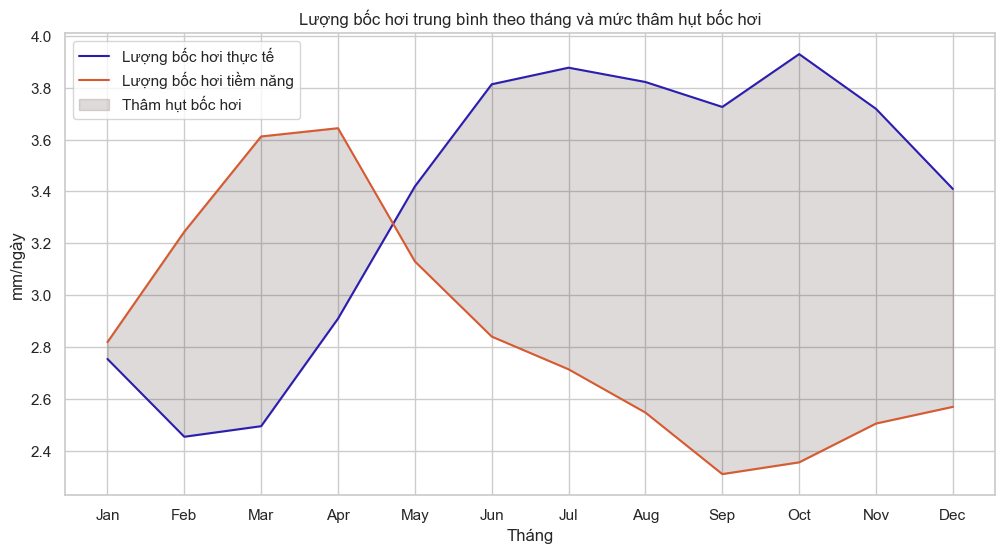

In [8]:
months = np.arange(1, 13)
fig, ax = plt.subplots(figsize=(12, 6))
ax.set_title("Lượng bốc hơi trung bình theo tháng và mức thâm hụt bốc hơi")
ax.plot(months, df_clim['evap'].values,  label="Lượng bốc hơi thực tế", color="#2B1DB1")
ax.plot(months, df_clim['pevap'].values, label="Lượng bốc hơi tiềm năng", color="#D85A30")
ax.fill_between(months, df_clim['evap'].values, df_clim['pevap'].values,
                alpha=0.15, color="#270D04", label="Thâm hụt bốc hơi")
ax.set_xticks(months)
ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun",
                    "Jul","Aug","Sep","Oct","Nov","Dec"])
ax.set_ylabel("mm/ngày")
ax.set_xlabel("Tháng")
ax.legend()

## 2. Chu kỳ mùa và xu hướng dài hạn của hệ số bốc hơi

Bên trái là DAILY_EF (evap / pevap), là tỉ số của lượng bốc hơi thực tế và lượng bốc hơi tiềm năng, cho thấy xu hướng theo mùa về áp lực bốc hơi ở bề mặt. Bên phải là biểu đồ thể hiện tỉ lệ EF này trung bình qua các năm. 

Nếu chỉ số EF này giảm, có nghĩa là lượng bốc hơi thực tế đang không thể theo kịp lượng bốc hơi tiềm năng. Điều này có nghĩa là về lâu dài, bề mặt đất sẽ bị khô cạn vì không có đủ nước để đáp ứng nhu cầu của khí quyển. 

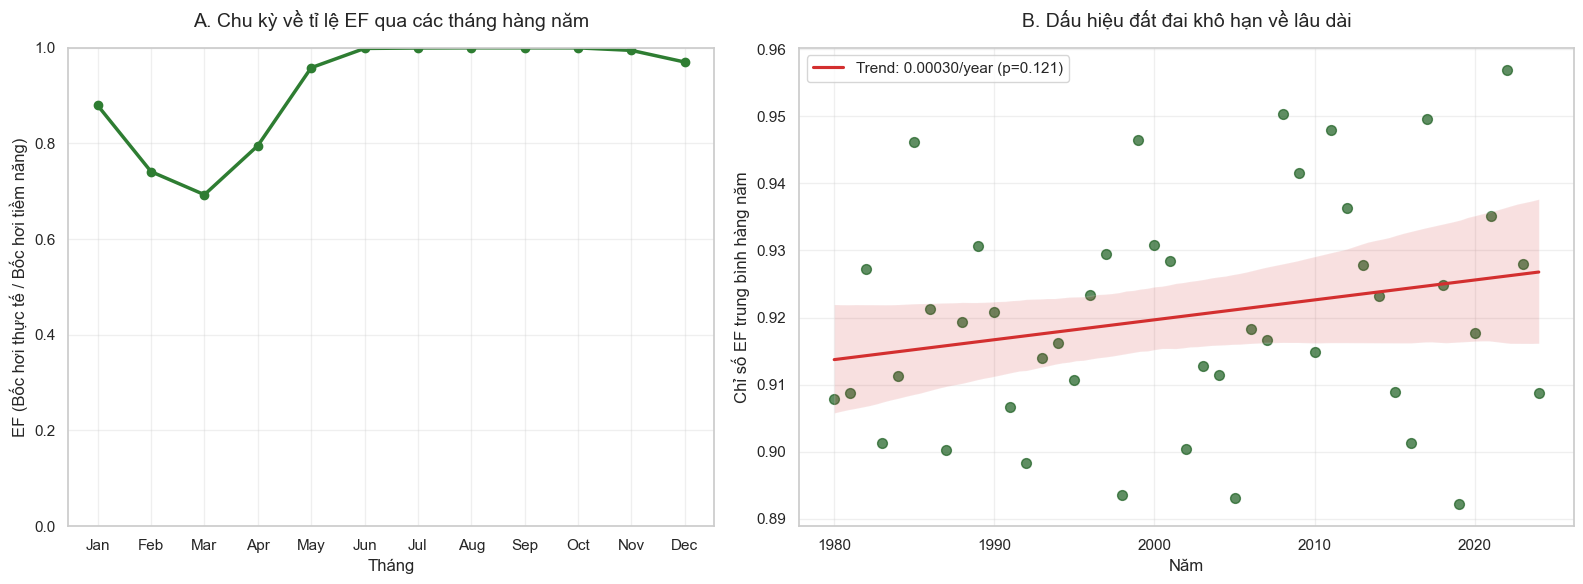

In [9]:
# Ensure time is the index for resampling
df_daily_idx = df_daily.set_index('time')
annual_ef = df_daily_idx['ef'].resample('YE').mean()
years = annual_ef.index.year
ef_values = annual_ef.values

# Calculate linear trend for the legend
slope, intercept, r_value, p_value, std_err = stats.linregress(years, ef_values)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={'width_ratios': [1, 1.2]})

# Left Panel: Monthly Climatological Mean
ax1.plot(df_clim['month'], df_clim['ef'], marker='o', color='#2E7D32', linewidth=2.5)
ax1.set_title("A. Chu kỳ về tỉ lệ EF qua các tháng hàng năm", fontsize=14, pad=15)
ax1.set_ylabel("EF (Bốc hơi thực tế / Bốc hơi tiềm năng)")
ax1.set_xlabel("Tháng")
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])
ax1.set_ylim(0, 1) # EF is 0-1 scale
ax1.grid(True, alpha=0.3)

# Right Panel: Annual Mean + Trend Line
sns.regplot(x=years, y=ef_values, ax=ax2, 
            scatter_kws={'s': 50, 'color': '#1B5E20', 'alpha': 0.7}, 
            line_kws={'color': '#D32F2F', 'label': f'Trend: {slope:.5f}/year (p={p_value:.3f})'})

ax2.set_title("B. Dấu hiệu đất đai khô hạn về lâu dài", fontsize=14, pad=15)
ax2.set_ylabel("Chỉ số EF trung bình hàng năm")
ax2.set_xlabel("Năm")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Heatmap mức độ thâm hụt bốc hơi qua các tháng trong các năm

DEF = Potential Evaporation - Evaporation, là chỉ số đo mức độ thâm hụt bốc hơi giữa lượng tiềm năng và lượng thực tế. Màu đỏ thể hiện rằng bầu khí quyển đang thiếu mức bốc hơi cần thiết, so với những gì bề mặt đất có thể đáp ứng được. 

Từ heatmap này, ta có thể nhận ra những thời điểm nào là những thời điểm khô hạn nặng, thường những thời điểm này sẽ đi kèm với biến động nhiệt độ cao, ít mưa và sự thâm hụt cũng cao một cách bất thường.

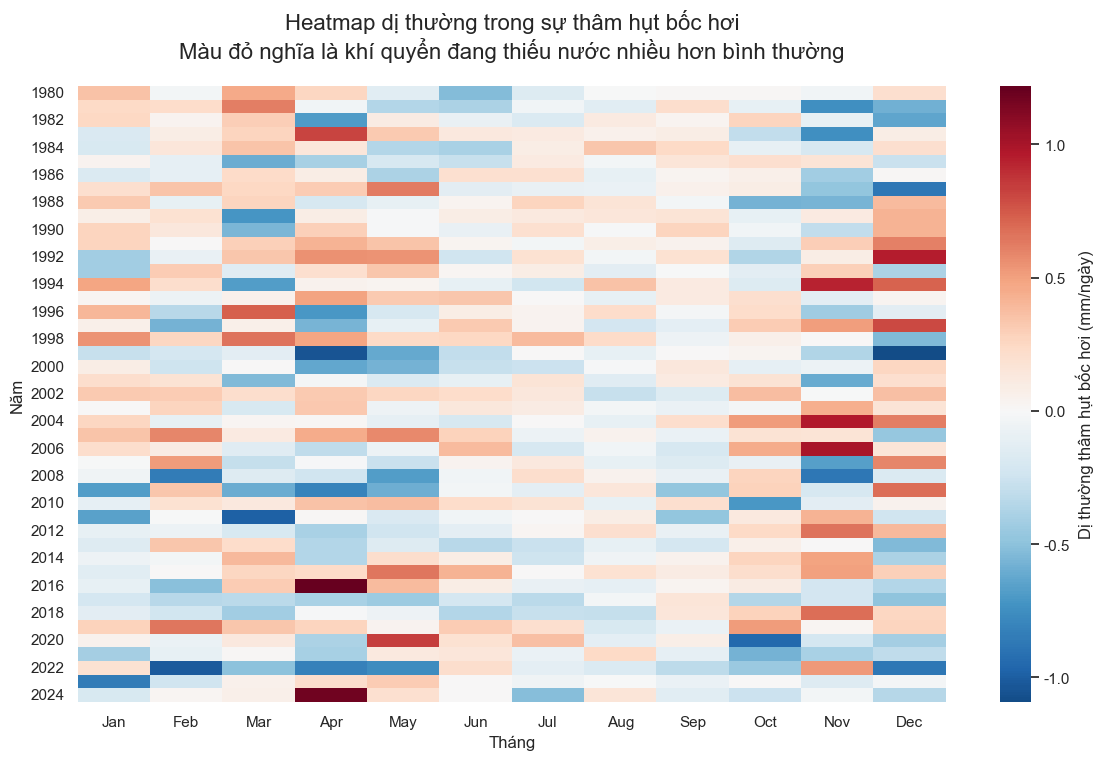

In [16]:
# Resample daily deficit to monthly means
df_monthly_def = df_daily_idx['def'].resample('MS').mean().to_frame()
df_monthly_def['month'] = df_monthly_def.index.month
df_monthly_def['year'] = df_monthly_def.index.year

# Calculate climatology for deficit (mean of each month across all years)
def_clim = df_monthly_def.groupby('month')['def'].mean()

# Subtract climatology to get the anomaly
df_monthly_def['def_anom'] = df_monthly_def.apply(
    lambda row: row['def'] - def_clim[row['month']], axis=1
)

# Pivot for the heatmap: Rows = Year, Columns = Month
heatmap_data = df_monthly_def.pivot(index="year", columns="month", values="def_anom")

plt.figure(figsize=(14, 8))

# Use RdBu_r (Red = Positive/Dryer, Blue = Negative/Wetter)
sns.heatmap(heatmap_data, cmap="RdBu_r", 
            center=0, 
            cbar_kws={'label': 'Dị thường thâm hụt bốc hơi (mm/ngày)'},
            annot=False)

plt.title("Heatmap dị thường trong sự thâm hụt bốc hơi\nMàu đỏ nghĩa là khí quyển đang thiếu nước nhiều hơn bình thường", 
          fontsize=16, pad=20)
plt.xlabel("Tháng")
plt.ylabel("Năm")
plt.xticks(ticks=np.arange(0.5, 12.5), labels=["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])

plt.show()

## 4. Xu hướng lâu dài

Ở đây, ta đã tách riêng 2 biểu đồ, lượng bốc hơi thực tế và lượng bốc hơi tiềm năng, được đo bằng lượng trung bình của từng năm. Hai biểu đồ đều có xu hướng tăng, dù lượng bốc hơi thực tế có vẻ tăng nhiều hơn so với lượng bốc hơi tiềm năng.



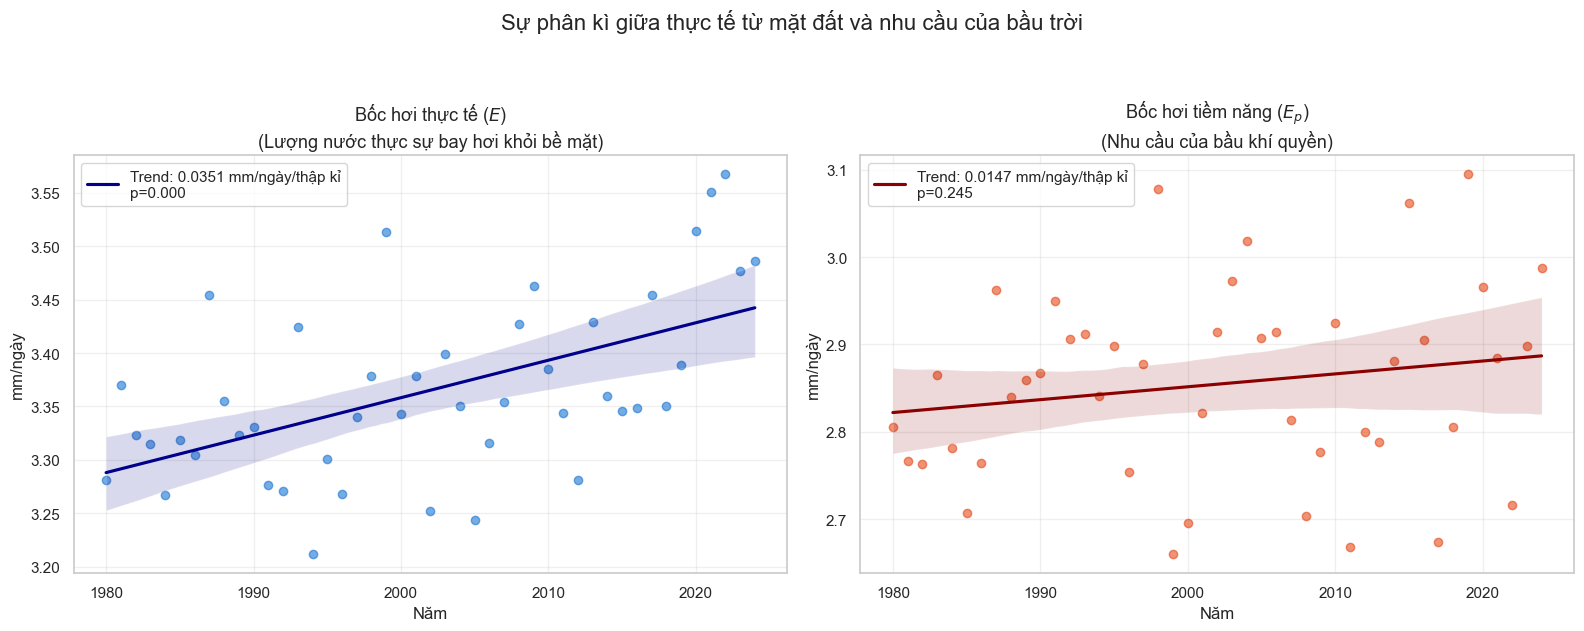

In [19]:
# Resample to annual means
df_annual = df_daily.set_index('time')[['evap', 'pevap']].resample('YE').mean()
years = df_annual.index.year

# Calculate trends for both
slope_act, intercept_act, _, p_act, _ = stats.linregress(years, df_annual['evap'])
slope_pot, intercept_pot, _, p_pot, _ = stats.linregress(years, df_annual['pevap'])

# Create the Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharex=True)

# Left Panel: Actual Evaporation
sns.regplot(x=years, y=df_annual['evap'], ax=ax1, 
            color='#1976D2', scatter_kws={'alpha':0.6},
            line_kws={'color': 'darkblue', 'label': f'Trend: {slope_act*10:.4f} mm/ngày/thập kỉ\np={p_act:.3f}'})
ax1.set_title("Bốc hơi thực tế ($E$)\n(Lượng nước thực sự bay hơi khỏi bề mặt)", fontsize=13)
ax1.set_ylabel("mm/ngày")
ax1.set_xlabel("Năm")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Right Panel: Potential Evaporation
sns.regplot(x=years, y=df_annual['pevap'], ax=ax2, 
            color='#E64A19', scatter_kws={'alpha':0.6},
            line_kws={'color': 'darkred', 'label': f'Trend: {slope_pot*10:.4f} mm/ngày/thập kỉ\np={p_pot:.3f}'})
ax2.set_title("Bốc hơi tiềm năng ($E_p$)\n(Nhu cầu của bầu khí quyền)", fontsize=13)
ax2.set_ylabel("mm/ngày")
ax2.set_xlabel("Năm")
ax2.legend()
ax2.grid(True, alpha=0.3)

# Add a main title explaining the logic
plt.suptitle("Sự phân kì giữa thực tế từ mặt đất và nhu cầu của bầu trời", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

## 5. Mức độ căng thẳng của nước

Stress ratio (Mức độ căng thẳng) của nước = Bốc hơi tiềm năng / Bốc hơi thực tế. Nếu chỉ số này ≈ 1, thì nghĩa là đủ nước từ mặt đất. Ngược lại, nếu chỉ số này >> 1, nghĩa là khô hạn nghiêm trọng đang xảy ra vì đất bị thiểu rất nhiều nước.

Đồng thời có thêm một biểu đồ nữa để đo xu hướng về lâu dài của chỉ số này. Đó chính là mức trung bình của chỉ số qua từng năm.

In [12]:
def get_season(month):
    if month in [12, 1, 2]: return 'DJF (Winter/Dry)'
    if month in [3, 4, 5]: return 'MAM (Spring)'
    if month in [6, 7, 8]: return 'JJA (Summer/Wet)'
    return 'SON (Autumn)'

df_daily['season'] = df_daily['time'].dt.month.map(get_season)
df_daily['decade'] = (df_daily['time'].dt.year // 10) * 10

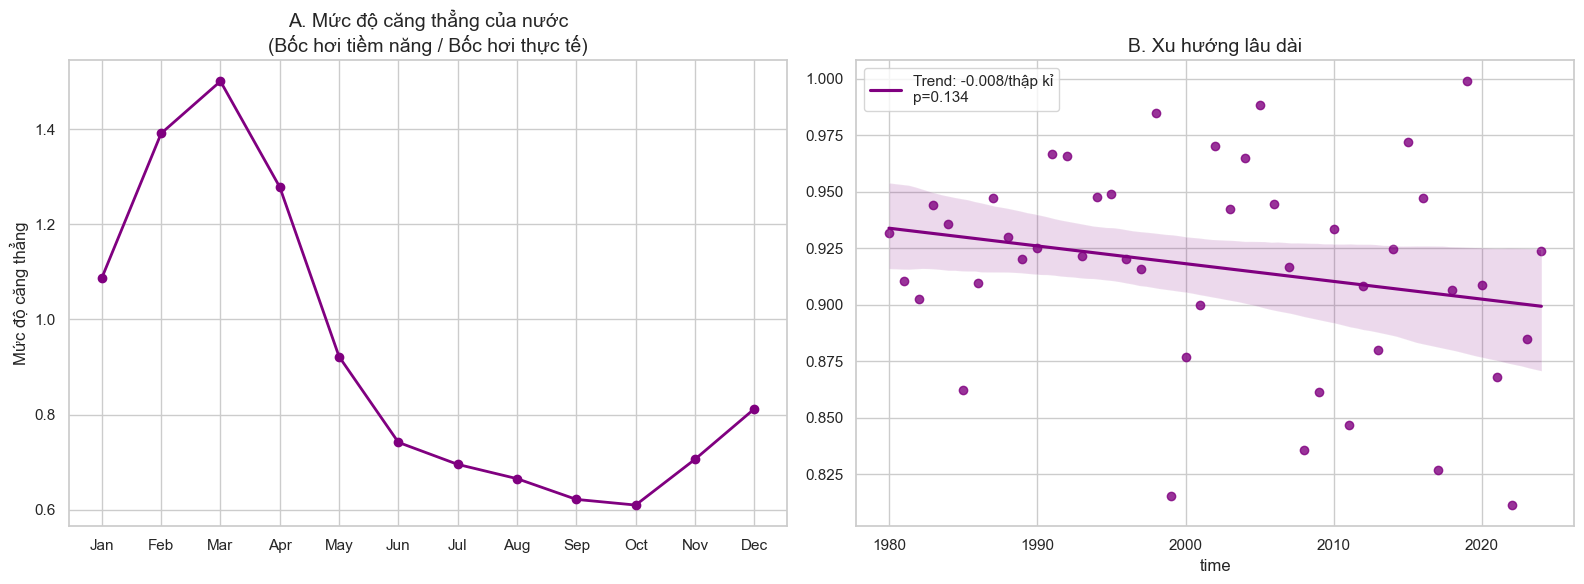

In [20]:
# Calculate Stress Ratio (avoiding division by zero)
df_daily['stress_ratio'] = df_daily['pevap'] / (df_daily['evap'] + 1e-6)

# Climatology and Annual Trend
clim_stress = df_daily.groupby(df_daily['time'].dt.month)['stress_ratio'].mean()
annual_stress = df_daily.set_index('time')['stress_ratio'].resample('YE').mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left: Seasonal Cycle
ax1.plot(range(1, 13), clim_stress, marker='o', color='purple', lw=2)
ax1.set_title("A. Mức độ căng thẳng của nước\n(Bốc hơi tiềm năng / Bốc hơi thực tế)", fontsize=14)
ax1.set_ylabel("Mức độ căng thẳng")
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])

# Right: Long-term Trend
slope, _, _, p, _ = stats.linregress(annual_stress.index.year, annual_stress.values)
sns.regplot(x=annual_stress.index.year, y=annual_stress.values, ax=ax2, color='purple',
            line_kws={'label': f'Trend: {slope*10:.3f}/thập kỉ\np={p:.3f}'})
ax2.set_title("B. Xu hướng lâu dài", fontsize=14)
ax2.legend()

plt.tight_layout()
plt.show()

## 6. So sánh sự phân bố theo từng thập kỉ

Sử dụng biểu đồ violin để làm phân phối CDF cho lượng bốc hơi thực tế xuyên suốt từng thập kỉ một, tách riêng giữa mùa mưa (tháng 5 - tháng 10) và mùa khô (tháng 11 - tháng 4).

Ta thấy đuôi trên thu hẹp dần trong mùa khô và ngược lại trong mùa mưa, tức là trong mùa khô sự bốc hơi ngày càng ít đi, và ngược lại trong mùa mưa.

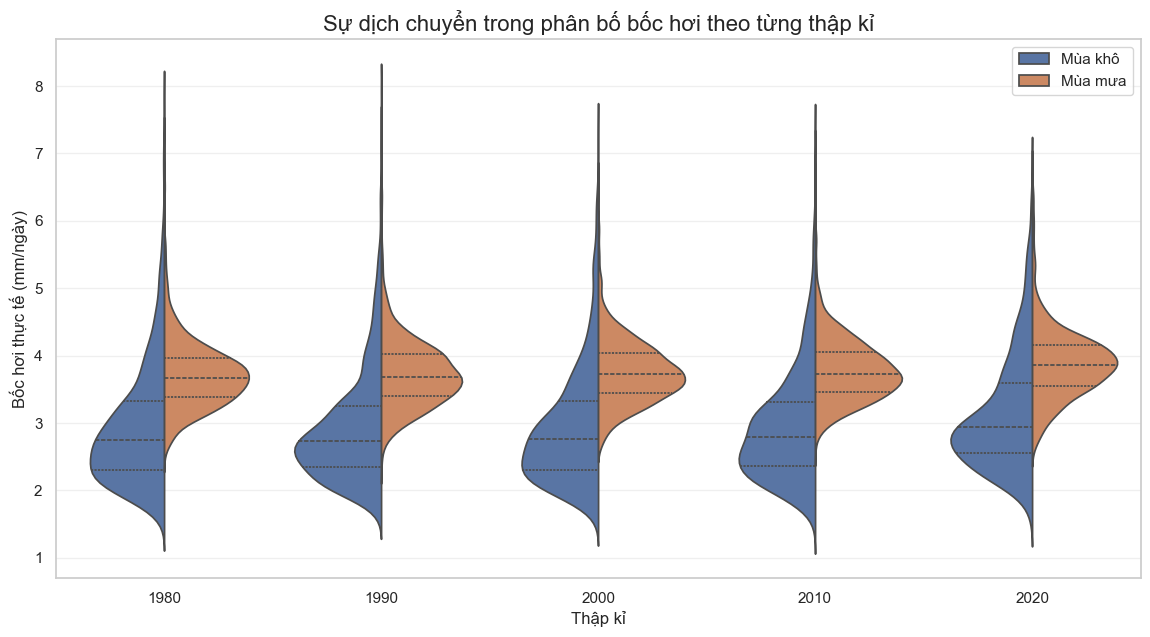

In [22]:
# Define Wet vs Dry seasons for your specific region
# Example: Wet = May-Oct, Dry = Nov-Apr
df_daily['season_type'] = df_daily['time'].dt.month.apply(lambda x: 'Mùa mưa' if 5 <= x <= 10 else 'Mùa khô')

plt.figure(figsize=(14, 7))
sns.violinplot(data=df_daily, x='decade', y='evap', hue='season_type', split=True, inner="quart")

plt.title("Sự dịch chuyển trong phân bố bốc hơi theo từng thập kỉ", fontsize=16)
plt.xlabel("Thập kỉ")
plt.ylabel("Bốc hơi thực tế (mm/ngày)")
plt.grid(axis='y', alpha=0.3)
plt.legend(loc='upper right')

plt.show()